# Week 5 (Dimension Reduction, SVM)

## Dimension Reduction

### `make_regression`을 이용한 PCA Regression

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html

scikit-learn에서는 `make_regression` 함수를 이용하여 회귀분석을 연습하기 위한 데이터셋을 만들 수 있다. 이를 이용해서 Principal Component Regression을 연습하는 과제를 진행해보자.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression

### Q1 `make_regression` 함수로 데이터를 생성해보자

독립변수는 X1부터 X10까지, 종속변수는 Y를 생성하자. 표본 크기는 1000으로 설정하고, `noise`, `random_state`, `bias`등의 변수는 자유롭게 설정해보자.

In [ ]:
# make_regression로 데이터 생성

X, y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=42, bias=0)

df_X = pd.DataFrame(X, columns=[f'X{i+1}' for i in range(10)])
df_y = pd.Series(y, name='Y')

### Q2 EDA를 해보자

각 변수별 히스토그램, scatterplot matrix, correlation matrix, 요약통계량(descriptive statistics)를 그려보자


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

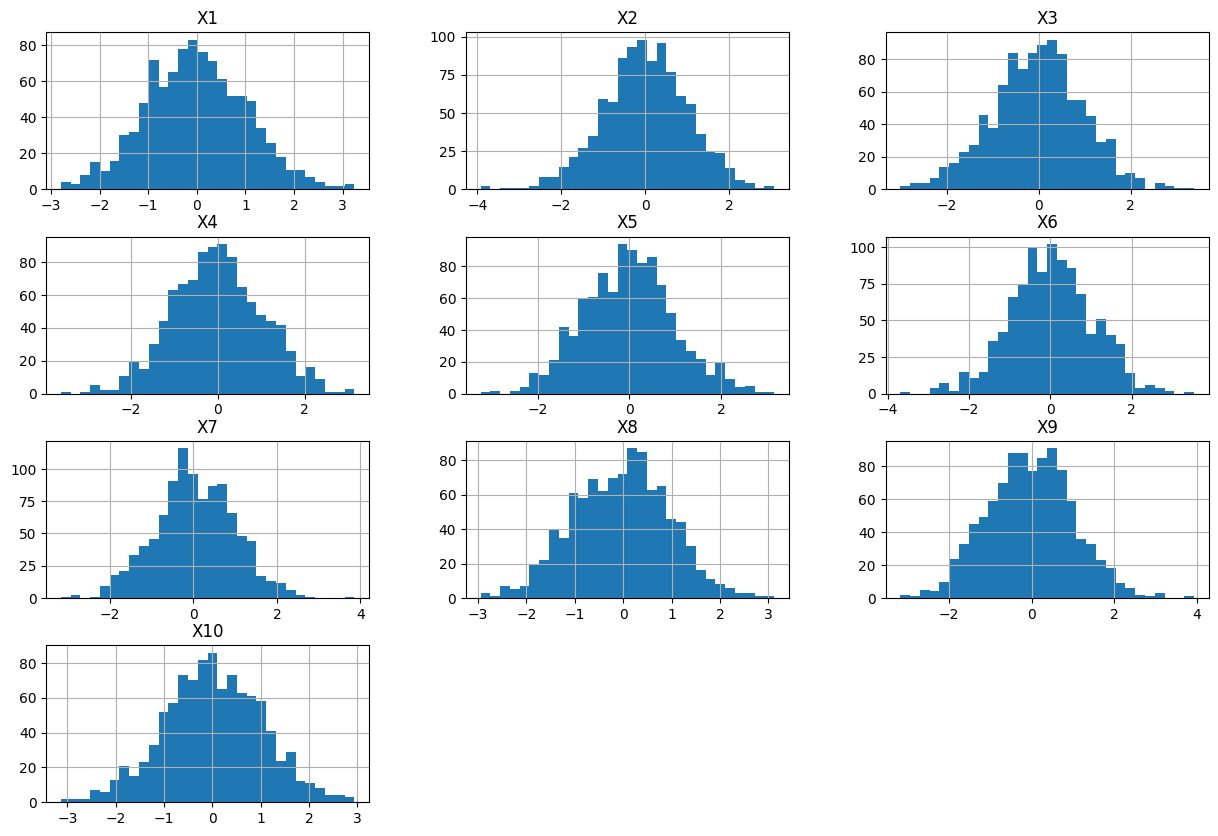

In [ ]:
# 히스토그램
df_X.hist(bins=30, figsize=(15, 10))
plt.show()

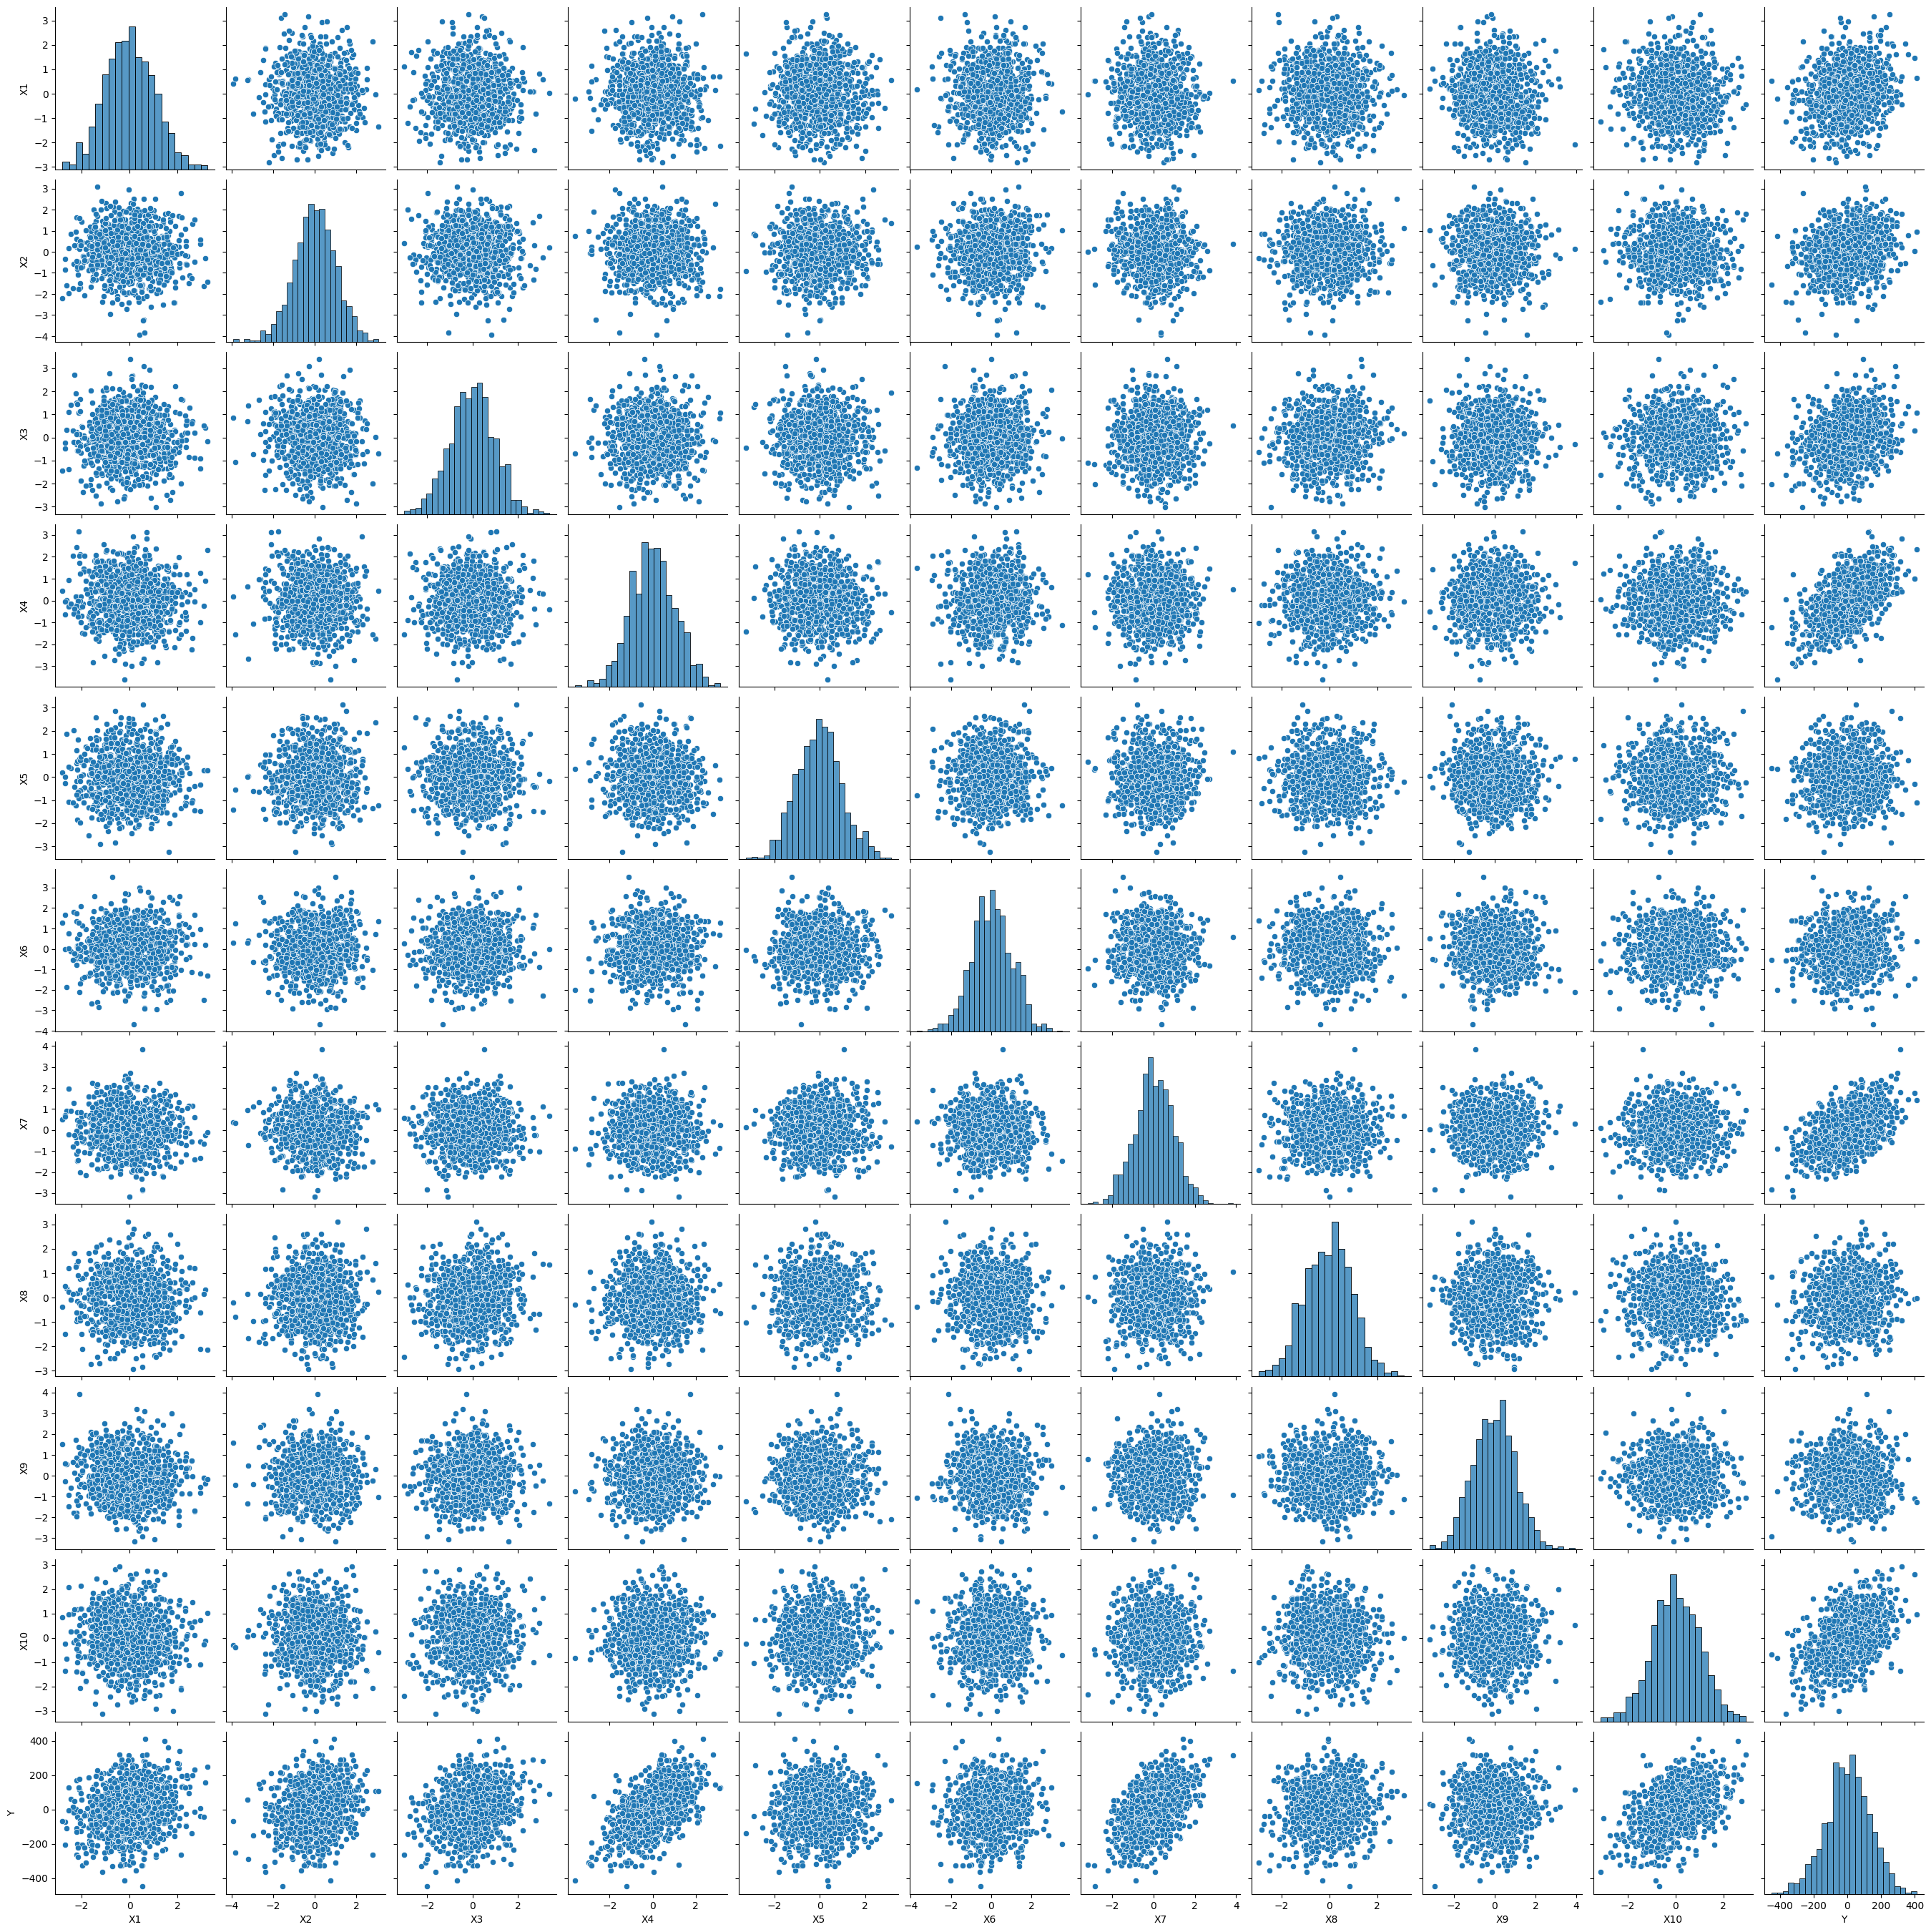

In [ ]:
# Scatterplot matrix
sns.pairplot(pd.concat([df_X.iloc[:, :10], df_y], axis=1))
plt.show()

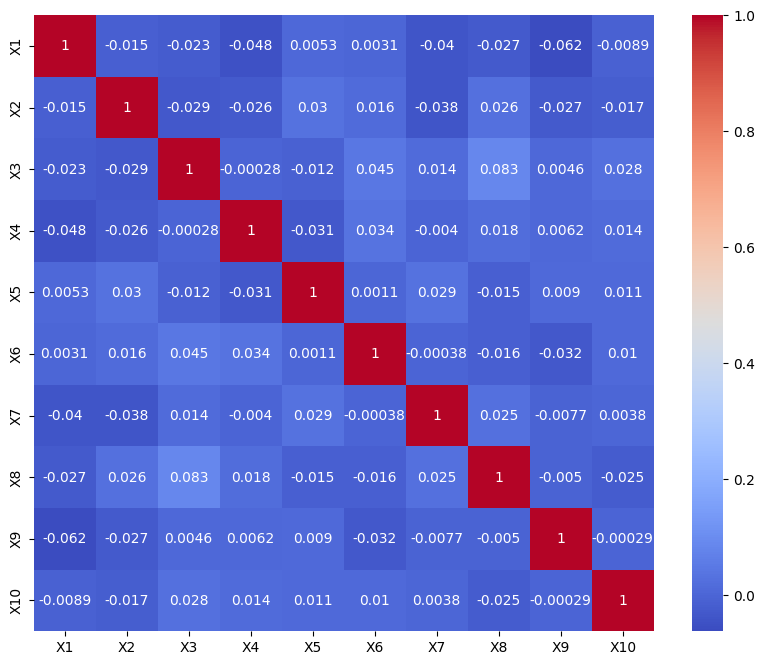

In [ ]:
# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_X.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# 요약 통계량
print(df_X.describe())

                X1           X2           X3           X4           X5  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     -0.002689     0.010788    -0.023104     0.005495    -0.022542   
std       1.031230     1.005433     0.986846     1.030962     0.983366   
min      -2.801912    -3.922400    -3.007632    -3.601085    -3.241267   
25%      -0.744779    -0.616527    -0.650034    -0.713176    -0.702626   
50%      -0.024976     0.014006    -0.003221    -0.013284    -0.015036   
75%       0.683319     0.679698     0.608861     0.696602     0.613766   
max       3.243093     3.076860     3.377383     3.137749     3.152057   

                X6           X7           X8           X9          X10  
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000  
mean      0.031292     0.038105    -0.043075    -0.029252     0.013622  
std       1.016046     0.945284     0.983406     1.037024     1.012645  
min      -3.688365    -3.176704    -2.943

### Q3 `StandardScaler` 로 scaling을 해보자

X 변수들에 대해 `StandarScaler`를 이용하여 표준화를 해보자.
PCA를 하기 전에 스케일링을 한다는 점을 유의하자.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 스케일링하기
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Q4 `PCA`를 해보자

`PCA` 함수를 이용하여 PCA를 해보자. 또 다음을 해보자.

- PC1 부터 PC10 까지 Scree plot을 그려보자
- PC1과 PC2를 가지고 scatterplot을 그려보자.

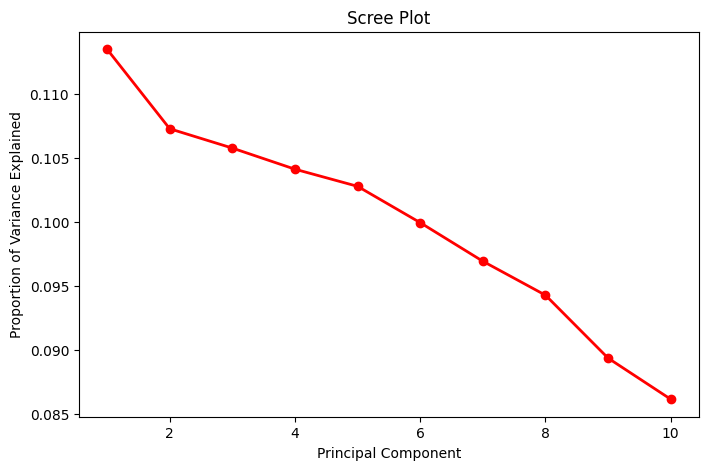

In [ ]:
from sklearn.decomposition import PCA

# PCA 계산하기
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Scree plot 그리기
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), pca.explained_variance_ratio_, 'ro-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.show()

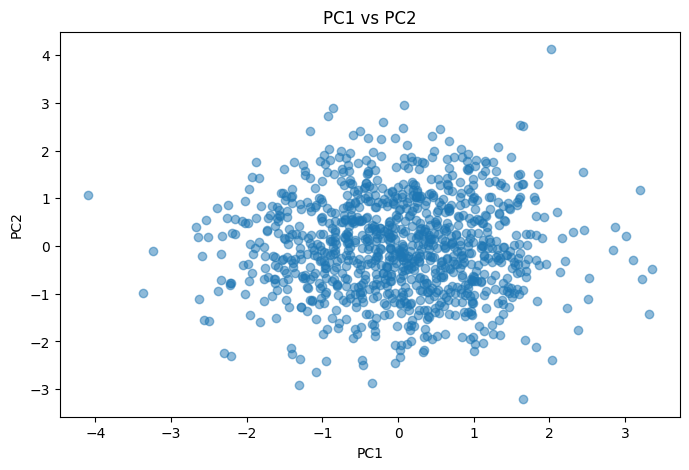

In [ ]:
# PC1 와 PC2 산점도 그리기
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1 vs PC2')
plt.show()

### Q5 `train_test_split`을 해보자

Train set과 Test set을 6:4 비율로 나눠보자

In [ ]:
from sklearn.model_selection import train_test_split

# train set과 test set 나누기
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.4, random_state=42)

###  Q6 Principal Component Regression을 진행해보자.

Q5에서 만든 데이터로부터 다음의 과정으로 문제를 풀어보자.
- Y를 종속변수(`y_train`), `X_train`의 PC1을 종속변수로 하여 Linear Regression을 적합한다.
- `y_pred`과 `y_train`을 비교하여 train error의 MSE를 구한다.
- Principal component을 하나 늘려 Linear regression을 적합한다. 즉 Y에 대해 PC1, PC2으로 Linear Regression을 적합한다.
- 마찬가지로 train error의 MSE를 구한다.
- PC10까지 같은 과정을 반복하고, MSE를 비교한다.



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# train MSE 저장
mse_train = []

# 회귀모형 적합
for i in range(1, 11):
    lr = LinearRegression()
    lr.fit(X_train[:, :i], y_train)

    # Train MSE
    y_train_pred = lr.predict(X_train[:, :i])
    mse_train.append(mean_squared_error(y_train, y_train_pred))

### Q7 Test error을 계산해보자.

위 과정에서 적합한 모형을 바탕으로 `y_test`을 추정하고 `y_test`와의 MSE를 계산하여 test error을 구해보자.

In [ ]:
# test MSE 저장
mse_test = []

for i in range(1, 11):
    lr = LinearRegression()
    lr.fit(X_train[:, :i], y_train)

    # Test MSE
    y_test_pred = lr.predict(X_test[:, :i])
    mse_test.append(mean_squared_error(y_test, y_test_pred))

for i, (tr, te) in enumerate(zip(mse_train, mse_test), 1):
    print(f"PC{i} | Train MSE: {tr:.4f} | Test MSE: {te:.4f}")

PC1 | Train MSE: 14414.9442 | Test MSE: 14645.2454
PC2 | Train MSE: 13959.2873 | Test MSE: 14103.5573
PC3 | Train MSE: 13431.0121 | Test MSE: 13405.3252
PC4 | Train MSE: 11361.4450 | Test MSE: 11187.1408
PC5 | Train MSE: 10566.0779 | Test MSE: 10374.6004
PC6 | Train MSE: 10234.6603 | Test MSE: 9734.3530
PC7 | Train MSE: 8160.4225 | Test MSE: 7762.8671
PC8 | Train MSE: 7297.8540 | Test MSE: 6572.6745
PC9 | Train MSE: 3482.8333 | Test MSE: 3278.3866
PC10 | Train MSE: 0.0091 | Test MSE: 0.0099


## SVM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.svm import SVC, SVR

- SVC (Classification)
- SVR (Regression)

### 1.1 Hard Margin Classifier

#### Q1.1 Hard Margin Classifier란? :

In [ ]:
# 데이터셋 생성
X = np.array([[1, 2], [2, 3], [3, 3], [6, 6], [7, 8], [8, 8]])
y = np.array([0, 0, 0, 1, 1, 1])

#### Q1.2 위 데이터셋을 2차원의 좌표평면에 시각화해주세요.

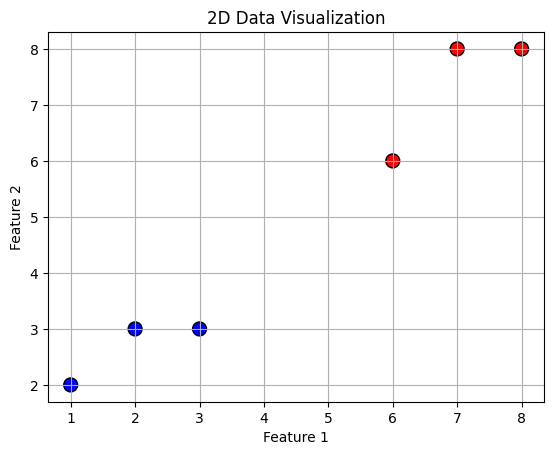

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('2D Data Visualization')
plt.grid(True)
plt.show()

In [ ]:
# Hard Margin SVM 모델 학습
model = SVC(kernel='linear', C=1e10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

#### Q1.3 하단 w와 b는 모델 학습으로 찾아낸 Wx+b의 계수와 상수항입니다. w와 b를 정의해주세요.

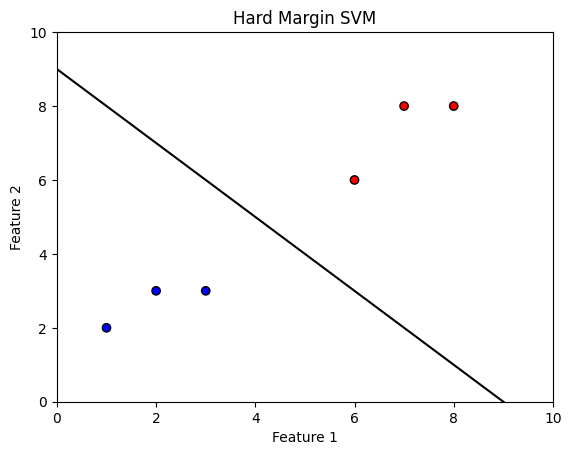

In [ ]:
# 결정 경계 시각화
w = model.coef_[0]
b = model.intercept_[0]
x_plot = np.linspace(0, 10, 100)
y_plot = -(w[0] * x_plot + b) / w[1]

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.plot(x_plot, y_plot, 'k-')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Hard Margin SVM')
plt.show()

### 1.2 Soft Margin Classifier

#### Q2.1 Soft Margin Classifier란?

#### Q2.2 Soft Margin의 정의를 떠올리며, 노이즈가 추가된 데이터셋을 생성해주세요. (2개 이상 추가 생성 필요)

In [ ]:
# 데이터셋 생성 (약간의 노이즈 추가)
X = np.array([[1, 2], [2, 3], [3, 3], [6, 6], [7, 8], [8, 8], [4, 4], [5, 5]])
y = np.array([0, 0, 0, 1, 1, 1, 1, 0])

In [ ]:
# Soft Margin SVM 모델 학습
model = SVC(kernel='linear', C=1.0)
model.fit(X, y)

SVC(kernel='linear')

#### Q2.3 마진을 산출해 시각화하고, Support Vector을 찾아주세요.

하단 그림은 예시로, 꼭 똑같이 출력되지 않아도 됩니다.

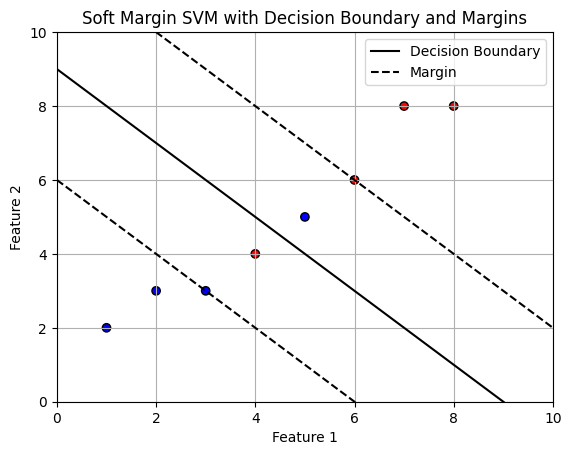

In [ ]:
# 결정 경계 시각화
w = model.coef_[0]
b = model.intercept_[0]
x_plot = np.linspace(0, 10, 100)
y_plot = -(w[0] * x_plot + b) / w[1]

# 마진 경계 계산
y_margin_positive = (1 - w[0] * x_plot - b) / w[1]
y_margin_negative = (-1 - w[0] * x_plot - b) / w[1]

# 마진 시각화
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.plot(x_plot, y_plot, 'k-', label='Decision Boundary')
plt.plot(x_plot, y_margin_positive, 'k--', label='Margin')
plt.plot(x_plot, y_margin_negative, 'k--')

plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Soft Margin SVM with Decision Boundary and Margins')
plt.legend()
plt.grid(True)
plt.show()

### 1.3 프로젝트 (SVC)

In [ ]:
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix

#### **Linear SVC**

In [ ]:
iris = load_iris()

X = iris.data[:, :2]
y = iris.target

C = 1
clf = SVC(kernel = "linear", C=C)
clf.fit(X,y)

SVC(C=1, kernel='linear')

In [ ]:
y_pred = clf.predict(X) # 학습 데이터의 재예측 (실습용)
confusion_matrix(y, y_pred) # 따라서, 분류 결과가 상당히 정확할 수밖에 없음을 감안해야 함

array([[50,  0,  0],
       [ 0, 38, 12],
       [ 0, 15, 35]])

#### Q3.1 위 예시처럼, 옵션을 linear로 설정해도 되지만, sklearn의 LinearSVC 함수를 사용해도 구현할 수 있습니다. LinearSVC로 재구현해주세요.

In [ ]:
from sklearn.svm import LinearSVC

clf_linear = LinearSVC(C=1, max_iter=10000, random_state=42)
clf_linear.fit(X, y)

y_pred_linear = clf_linear.predict(X)

confusion_matrix(y, y_pred_linear)

array([[49,  1,  0],
       [ 2, 30, 18],
       [ 0,  9, 41]])

#### **Kernal SVC**

#### Q3.2 Kernel SCV - non-linear한 형태의 SVM을 하나 이상 구현해주세요. 동일하게, 학습데이터를 predict하여 confusion matrix를 구해주세요.

In [ ]:
from sklearn.svm import SVC

# RBF 커널
clf_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
clf_rbf.fit(X, y)

# Confusion Matrix
y_pred_rbf = clf_rbf.predict(X)
confusion_matrix(y, y_pred_rbf)

array([[50,  0,  0],
       [ 0, 38, 12],
       [ 0, 15, 35]])

#### 시각화

#### Q3.3 아래 예시 plot처럼, linear model과 non-linear 모델의 시각화 결과를 출력해주세요.

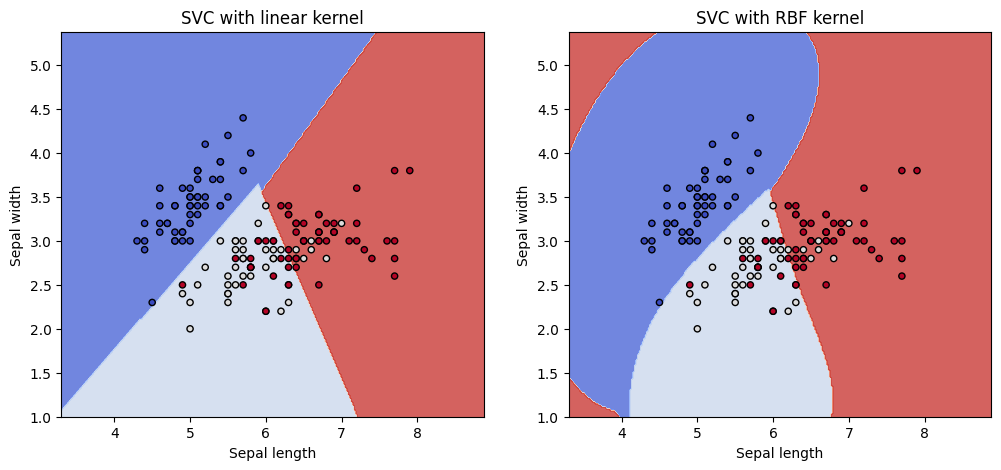

In [ ]:
def make_meshgrid(x, y, h=.02):
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

models = (SVC(kernel='linear', C=1.0),
          SVC(kernel='rbf', gamma=0.7, C=1.0))
models = [clf.fit(X, y) for clf in models]

titles = ('SVC with linear kernel', 'SVC with RBF kernel')
fig, sub = plt.subplots(1, 2, figsize=(12, 5))

X0, X1 = X[:, 0], X[:, 1]
xx, yy = make_meshgrid(X0, X1)

for clf, title, ax in zip(models, titles, sub.flatten()):
    plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('Sepal length')
    ax.set_ylabel('Sepal width')
    ax.set_title(title)

plt.show()